# Customer Analytics Dashboard

This notebook analyzes e-commerce customer behavior to identify high-value segments and improve business decisions.

**Sections:**
1. Data Quality Check
2. Business Metrics Overview
3. Time Trends (2021-2025)
4. Customer Segmentation (RFM)
5. Customer Demographics
6. Product Performance
7. Discount Impact
8. Returns Analysis
9. Strategic Recommendations

In [14]:
# Setup: Import libraries and configure plotting
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import plotly.express as px
import plotly.io as pio
from IPython.display import display

# Configure display and plotting
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pio.renderers.default = 'vscode'

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


In [15]:
# Utility Functions (extracted to avoid code duplication)

def safe_profit_margin(profit, sales):
    """Calculate profit margin % safely, handling zero sales."""
    return np.where(sales > 0, (profit / sales) * 100, 0)

def format_currency(x, pos):
    """Format axis labels as currency."""
    return f'${x:,.0f}'

def format_percentage(x, pos):
    """Format axis labels as percentage."""
    return f'{x:.1f}%'

def add_bar_labels(ax, fmt=',.0f'):
    """Add value labels on top of bars in a chart."""
    for p in ax.patches:
        height = p.get_height()
        if not np.isnan(height):
            ax.annotate(f'{height:{fmt}}',
                       (p.get_x() + p.get_width() / 2., height),
                       ha='center', va='bottom', fontsize=9,
                       xytext=(0, 3), textcoords='offset points')

def aggregate_performance(df, group_cols):
    """Standard aggregation for sales/profit/count metrics."""
    agg_dict = {
        'net_sales': 'sum',
        'profit': 'sum',
        'order_id': 'nunique',
        'quantity': 'sum'
    }
    
    result = df.groupby(group_cols).agg({
        k: v for k, v in agg_dict.items() if k in df.columns
    }).reset_index()
    
    # Rename for clarity
    rename_map = {
        'net_sales': 'total_sales',
        'profit': 'total_profit',
        'order_id': 'order_count',
        'quantity': 'total_qty'
    }
    result.rename(columns={k: v for k, v in rename_map.items() if k in result.columns}, inplace=True)
    
    # Add profit margin
    if 'total_profit' in result.columns and 'total_sales' in result.columns:
        result['margin_pct'] = safe_profit_margin(result['total_profit'], result['total_sales'])
    
    return result

print('✅ Utility functions defined')

✅ Utility functions defined


In [16]:
# Load and merge all data sources
print('Loading datasets...')

data_path = '../data/'
required_files = {
    'customers': 'customer_master.csv',
    'sales': 'ecommerce_sales_customer_analytics_150k.csv',
    'order_items': 'order_items.csv',
    'products': 'product_catalog.csv'
}

# Load with error handling
dataframes = {}
for name, filename in required_files.items():
    try:
        dataframes[name] = pd.read_csv(data_path + filename)
        print(f'  ✅ {filename}: {len(dataframes[name]):,} rows')
    except FileNotFoundError:
        raise FileNotFoundError(f'❌ Missing required file: {data_path}{filename}')

customers = dataframes['customers']
sales = dataframes['sales']
order_items = dataframes['order_items']
products = dataframes['products']

# Parse dates with error handling
sales['order_date'] = pd.to_datetime(sales['order_date'], errors='coerce')
if sales['order_date'].isna().any():
    print(f'  ⚠️  Warning: {sales["order_date"].isna().sum()} invalid dates converted to NaT')

# Create temporal features once
sales['order_month'] = sales['order_date'].dt.to_period('M')
sales['order_quarter'] = sales['order_date'].dt.to_period('Q')
sales['order_year'] = sales['order_date'].dt.year
sales['month_num'] = sales['order_date'].dt.month

# Validate product catalog uniqueness
if products['product_id'].duplicated().any():
    print(f'  ⚠️  Warning: {products["product_id"].duplicated().sum()} duplicate product_ids found')
    products = products.drop_duplicates(subset=['product_id'], keep='first')

print('\nMerging datasets...')
# Join order items with products
master_df = pd.merge(order_items, products, on='product_id', how='left', suffixes=('', '_prod'))

# Join with sales data
master_df = pd.merge(master_df, sales, on='order_id', how='left', suffixes=('', '_sales'))

# Join customer acquisition cost
master_df = pd.merge(
    master_df,
    customers[['customer_id', 'customer_acquisition_cost']],
    on='customer_id',
    how='left'
)

# Clean return status and coupon codes
master_df['return_status'] = master_df['return_status'].fillna('No Return')
master_df['return_reason'] = master_df['return_reason'].fillna('No Return')
master_df['coupon_code'] = master_df['coupon_code'].fillna('No Coupon')

# Normalize discount percentage (handle mixed units: 0-1 vs 0-100)
raw_discount = pd.to_numeric(master_df['discount_percentage'], errors='coerce').fillna(0)
master_df['discount_percentage'] = np.where(raw_discount <= 1, raw_discount * 100, raw_discount)

print(f'\n✅ Master dataset created: {master_df.shape[0]:,} rows × {master_df.shape[1]} columns')
print(f'   Unique customers: {master_df["customer_id"].nunique():,}')
print(f'   Unique orders: {master_df["order_id"].nunique():,}')
print(f'   Date range: {master_df["order_date"].min()} to {master_df["order_date"].max()}')

display(master_df.head(3))

Loading datasets...
  ✅ customer_master.csv: 25,000 rows
  ✅ ecommerce_sales_customer_analytics_150k.csv: 138,116 rows
  ✅ order_items.csv: 397,569 rows
  ✅ product_catalog.csv: 1,175 rows

Merging datasets...

✅ Master dataset created: 397,569 rows × 70 columns
   Unique customers: 24,911
   Unique orders: 138,116
   Date range: 2021-01-01 00:00:00 to 2025-12-31 00:00:00


,order_id,product_id,quantity,unit_price,discount_percentage,discount_amount,gross_sales,tax_amount,shipping_cost,net_sales,product_cost,profit,product_name,product_category,product_subcategory,brand,supplier,unit_price_prod,product_cost_prod,product_rating,order_date,order_time,order_status,sales_channel,customer_id,customer_name,customer_age,gender,customer_segment,customer_type,customer_city,customer_state,customer_country,region,customer_postal_code,payment_method,payment_status,currency,shipping_method,warehouse,delivery_days,estimated_delivery_days,delivery_status,return_status,return_reason,customer_rating,review_sentiment,customer_review,marketing_channel,campaign_name,coupon_code,loyalty_points_earned,loyalty_points_redeemed,quantity_sales,gross_sales_sales,discount_amount_sales,tax_amount_sales,shipping_cost_sales,net_sales_sales,product_cost_sales,profit_sales,profit_margin_percentage,customer_lifetime_value,is_repeat_customer,customer_order_count,order_month,order_quarter,order_year,month_num,customer_acquisition_cost
0,ORD-301242,PROD-000738,2,244.40,33.960729,166.00,488.80,22.60,6.48,351.88,173.28,172.12,Garmin Total client-driven task-force Medical ...,Health & Wellness,Medical Devices,Garmin,Euro Logistics,244.40,86.64,4.8,2023-11-06,16:37:47,Completed,Mobile App,CUST-003102,Jasmine Ryan,55,Male,Consumer,Loyal,Lake Williamberg,Texas,USA,South,86040,Digital Wallet,Paid,USD,Standard,WH-003,3.0,3.0,On Time,No Return,No Return,3.5,Positive,Satisfied with the purchase.,Direct,Default_Campaign,No Coupon,94,44,5,1350.19,477.89,61.07,12.03,945.40,588.33,345.04,36.50,12459.68,True,11,2023-11,2023Q4,2023,11,73.06
1,ORD-301242,PROD-000181,3,287.13,36.207588,311.89,861.39,38.47,5.55,593.52,415.05,172.92,Tommy Hilfiger Open-architected full-range foc...,Fashion,Shoes,Tommy Hilfiger,Pacific Trade,287.13,138.35,3.0,2023-11-06,16:37:47,Completed,Mobile App,CUST-003102,Jasmine Ryan,55,Male,Consumer,Loyal,Lake Williamberg,Texas,USA,South,86040,Digital Wallet,Paid,USD,Standard,WH-003,3.0,3.0,On Time,No Return,No Return,3.5,Positive,Satisfied with the purchase.,Direct,Default_Campaign,No Coupon,94,44,5,1350.19,477.89,61.07,12.03,945.40,588.33,345.04,36.50,12459.68,True,11,2023-11,2023Q4,2023,11,73.06
2,ORD-773460,PROD-000973,4,754.80,46.829957,1413.89,3019.20,305.01,9.00,1919.32,1976.16,-65.84,Swarovski Re-engineered discrete monitoring Ea...,Jewelry,Earrings,Swarovski,MultiSource,754.80,494.04,3.5,2025-12-24,01:22:36,Completed,Website,CUST-003124,Scott Chase,26,Male,Premium,Loyal,Kristyport,Baden-Württemberg,Germany,South,62538,Debit Card,Pending,EUR,Economy,WH-005,10.0,10.0,On Time,No Return,No Return,3.6,Positive,Good value for money.,Direct,Default_Campaign,No Coupon,201,171,8,3144.64,1456.06,320.83,9.00,2018.41,2031.88,-22.47,-1.11,13032.48,True,11,2025-12,2025Q4,2025,12,67.27


## 1. Data Quality Check

Before analyzing, we verify data completeness and identify quality issues.

In [17]:
# Check for missing values
missing = master_df.isnull().sum()
missing_pct = (missing / len(master_df) * 100).sort_values(ascending=False)
missing_report = missing_pct[missing_pct > 0]

print('='*60)
print('MISSING VALUES REPORT')
print('='*60)
print(f'Total columns: {master_df.shape[1]}')
print(f'Columns with missing data: {len(missing_report)}')
print('='*60)

if len(missing_report) > 0:
    missing_df = pd.DataFrame({
        'Column': missing_report.index,
        'Missing Count': missing[missing_report.index].values,
        'Missing %': missing_report.values.round(2)
    }).reset_index(drop=True)
    display(missing_df)
else:
    print('✅ No missing values found')

MISSING VALUES REPORT
Total columns: 70
Columns with missing data: 6


,Column,Missing Count,Missing %
0,campaign_name,239759,60.31
1,review_sentiment,70541,17.74
2,customer_rating,70541,17.74
3,customer_review,70541,17.74
4,delivery_days,70541,17.74
5,estimated_delivery_days,70541,17.74


In [18]:
# Check for duplicates at the expected grain
print('='*60)
print('DUPLICATE DETECTION')
print('='*60)

full_dupes = master_df.duplicated().sum()
grain_dupes = master_df.duplicated(subset=['order_id', 'product_id']).sum()

print(f'Full row duplicates: {full_dupes:,}')
print(f'Duplicates at (order_id, product_id) grain: {grain_dupes:,}')

if grain_dupes > 0:
    print(f'\n⚠️  {grain_dupes:,} duplicate order-product pairs detected')
    print('   These may represent multiple purchases of the same item in one order.')
else:
    print('\n✅ No duplicates at expected grain')

# Order size distribution
items_per_order = master_df.groupby('order_id').size()
print(f'\nItems per order: min={items_per_order.min()}, '
      f'median={items_per_order.median():.0f}, '
      f'max={items_per_order.max()}')

DUPLICATE DETECTION
Full row duplicates: 0
Duplicates at (order_id, product_id) grain: 87

⚠️  87 duplicate order-product pairs detected
   These may represent multiple purchases of the same item in one order.

Items per order: min=1, median=3, max=18


### Data Quality Summary

**Key findings:**
- Missing return data is expected (93% of orders were not returned)
- Missing coupons indicate no coupon was used (80% of orders)
- Small number of duplicate order-product pairs may be legitimate repeat purchases
- Data types validated successfully

## 2. Business Metrics Overview

High-level KPIs showing overall business health.

In [19]:
# Calculate key business metrics
total_revenue = master_df['net_sales'].sum()
total_profit = master_df['profit'].sum()

# Safe margin calculation
avg_profit_margin = (total_profit / total_revenue * 100) if total_revenue > 0 else 0

avg_order_value = master_df.groupby('order_id')['net_sales'].sum().mean()
total_customers = master_df['customer_id'].nunique()
total_orders = master_df['order_id'].nunique()

print('='*40)
print('BUSINESS DASHBOARD')
print('='*40)
print(f'Total Revenue:      ${total_revenue:,.2f}')
print(f'Total Profit:       ${total_profit:,.2f}')
print(f'Profit Margin:      {avg_profit_margin:.2f}%')
print(f'Avg Order Value:    ${avg_order_value:,.2f}')
print(f'Total Customers:    {total_customers:,}')
print(f'Total Orders:       {total_orders:,}')
print('='*40)

BUSINESS DASHBOARD
Total Revenue:      $192,398,877.29
Total Profit:       $82,698,038.55
Profit Margin:      42.98%
Avg Order Value:    $1,393.02
Total Customers:    24,911
Total Orders:       138,116


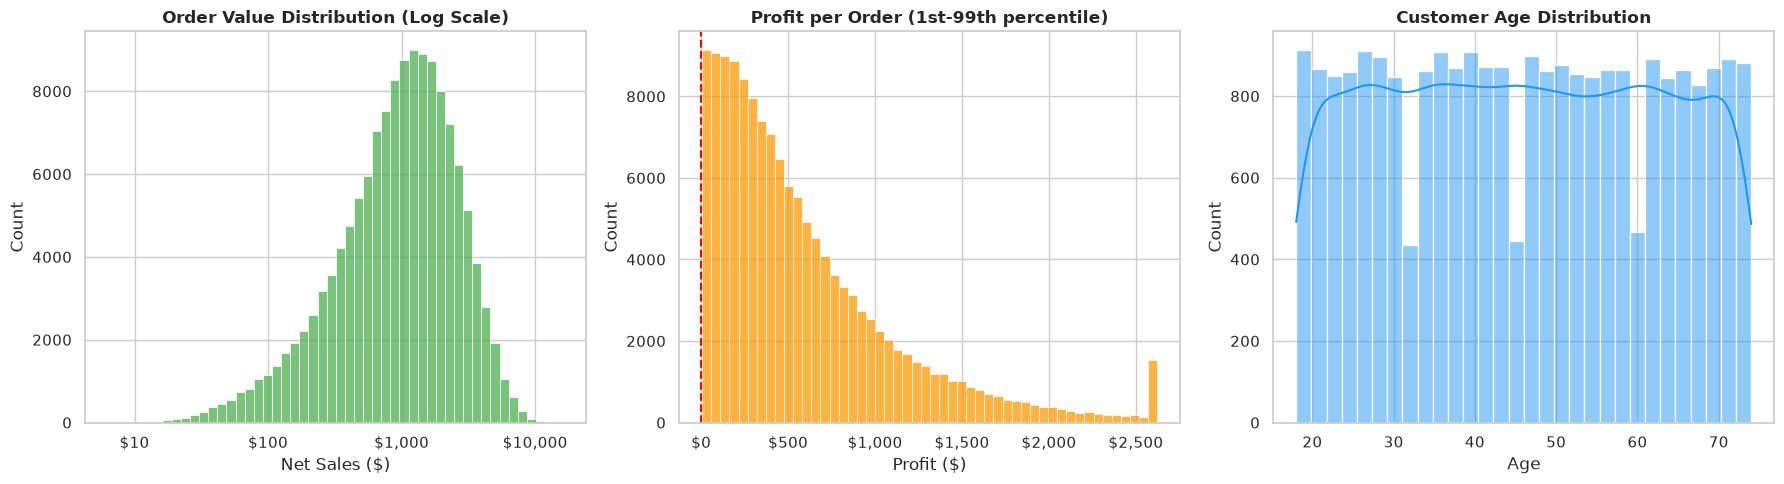

In [20]:
# Visualize key distributions
order_level = master_df.groupby('order_id')[['net_sales', 'profit']].sum()
customer_age = master_df.drop_duplicates('customer_id')['customer_age'].dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Order value (log scale due to outliers)
sns.histplot(order_level['net_sales'], bins=50, ax=axes[0], color='#4CAF50', log_scale=(True, False))
axes[0].set_title('Order Value Distribution (Log Scale)', fontweight='bold')
axes[0].set_xlabel('Net Sales ($)')
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(format_currency))

# Profit per order
p1, p99 = order_level['profit'].quantile([0.01, 0.99])
sns.histplot(order_level['profit'].clip(p1, p99), bins=50, ax=axes[1], color='#FF9800')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Profit per Order (1st-99th percentile)', fontweight='bold')
axes[1].set_xlabel('Profit ($)')
axes[1].xaxis.set_major_formatter(ticker.FuncFormatter(format_currency))

# Customer age
sns.histplot(customer_age, bins=30, ax=axes[2], color='#2196F3', kde=True)
axes[2].set_title('Customer Age Distribution', fontweight='bold')
axes[2].set_xlabel('Age')

plt.tight_layout()
plt.show()

### Key Insights

- **Strong profitability:** 43% profit margin on $192M revenue
- **High order value:** Average order worth $1,393
- **Customer base:** ~25,000 unique customers driving 138,000 orders
- **Age distribution:** Mature customer base (peak at 50+ years)

## 3. Time Trends (2021-2025)

Analysis of revenue patterns over time to identify seasonal trends.

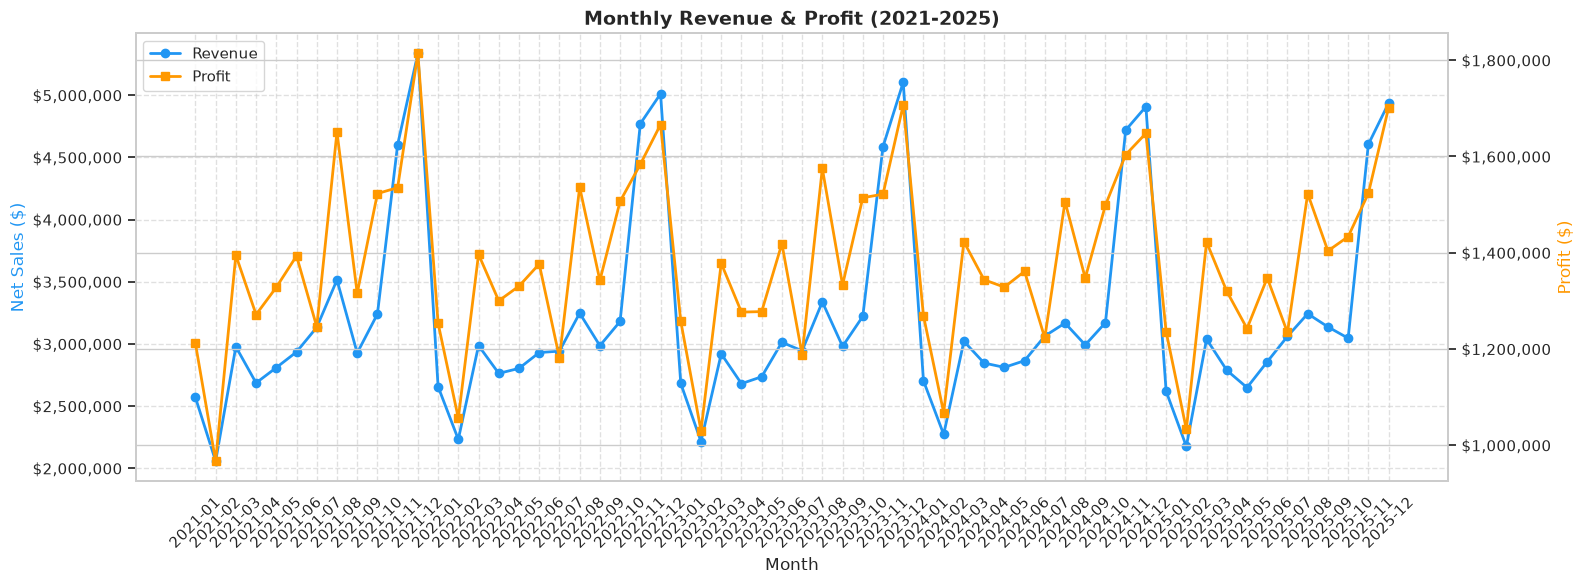

In [21]:
# Monthly revenue and profit trends
monthly_trends = master_df.groupby(master_df['order_month'].astype(str))[['net_sales', 'profit']].sum()

fig, ax = plt.subplots(figsize=(16, 6))
ax2 = ax.twinx()

ax.plot(monthly_trends.index, monthly_trends['net_sales'], 
        color='#2196F3', marker='o', linewidth=2, label='Revenue')
ax2.plot(monthly_trends.index, monthly_trends['profit'], 
         color='#FF9800', marker='s', linewidth=2, label='Profit')

ax.set_title('Monthly Revenue & Profit (2021-2025)', fontweight='bold', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Net Sales ($)', color='#2196F3')
ax2.set_ylabel('Profit ($)', color='#FF9800')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_currency))
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(format_currency))
ax.grid(True, linestyle='--', alpha=0.6)

# Combine legends
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()


SEASONAL COMPARISON


,net_sales,profit,margin_pct
is_holiday,,,
Holiday (Nov-Dec),4.857226e+07,16304146.64,33.57
Rest of Year,1.438266e+08,66393891.91,46.16


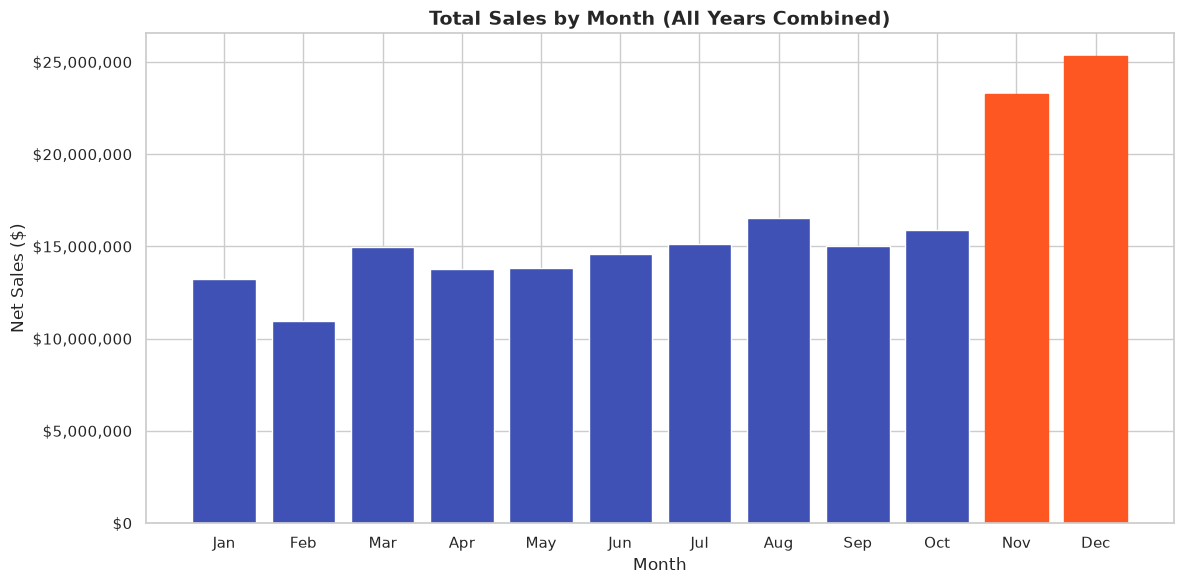

In [22]:
# Holiday season impact
master_df['is_holiday'] = master_df['month_num'].isin([11, 12])
season_label = master_df['is_holiday'].map({True: 'Holiday (Nov-Dec)', False: 'Rest of Year'})

season_metrics = master_df.groupby(season_label)[['net_sales', 'profit']].sum()
season_metrics['margin_pct'] = safe_profit_margin(season_metrics['profit'], season_metrics['net_sales'])

print('\nSEASONAL COMPARISON')
print('='*60)
display(season_metrics.round(2))

# Visualize
monthly_sales = master_df.groupby('month_num')['net_sales'].sum().sort_index()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(range(12), monthly_sales.values, color='#3F51B5')
bars[10].set_color('#FF5722')  # Highlight November
bars[11].set_color('#FF5722')  # Highlight December

ax.set_xticks(range(12))
ax.set_xticklabels(month_names)
ax.set_title('Total Sales by Month (All Years Combined)', fontweight='bold', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Net Sales ($)')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_currency))

plt.tight_layout()
plt.show()

### Time Trend Insights

- **Stable baseline:** Annual revenue steady at ~$35-36M per year
- **Holiday spike:** November and December drive 25% of annual revenue
- **February low:** Post-holiday cooldown creates a seasonal trough
- **Opportunity:** Targeted campaigns in Q1 could smooth revenue

## 4. Customer Segmentation (RFM Analysis)

RFM (Recency, Frequency, Monetary) scoring identifies high-value customer segments.

In [23]:
# Calculate RFM scores
ref_date = master_df['order_date'].max() + pd.Timedelta(days=1)

rfm_df = master_df.groupby('customer_id').agg(
    recency=('order_date', lambda x: (ref_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('net_sales', 'sum')
).reset_index()

# Quintile scoring (1-5, with duplicates handling)
rfm_df['R_Score'] = pd.qcut(rfm_df['recency'], q=5, labels=[5, 4, 3, 2, 1], 
                             duplicates='drop').astype(int)
rfm_df['F_Score'] = pd.qcut(rfm_df['frequency'].rank(method='first'), q=5, 
                             labels=[1, 2, 3, 4, 5], duplicates='drop').astype(int)
rfm_df['M_Score'] = pd.qcut(rfm_df['monetary'], q=5, labels=[1, 2, 3, 4, 5], 
                             duplicates='drop').astype(int)

rfm_df['RFM_Score'] = (rfm_df['R_Score'].astype(str) + 
                       rfm_df['F_Score'].astype(str) + 
                       rfm_df['M_Score'].astype(str))

# Assign business segments
def assign_segment(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 3:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2:
        return 'Lost'
    else:
        return 'Hibernating'

rfm_df['RFM_Segment'] = rfm_df.apply(assign_segment, axis=1)

# Segment summary
rfm_summary = rfm_df.groupby('RFM_Segment').agg(
    customer_count=('customer_id', 'count'),
    avg_recency_days=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    total_revenue=('monetary', 'sum')
).reset_index()

rfm_summary['customer_share_%'] = (rfm_summary['customer_count'] / rfm_summary['customer_count'].sum()) * 100
rfm_summary['revenue_share_%'] = (rfm_summary['total_revenue'] / rfm_summary['total_revenue'].sum()) * 100
rfm_summary = rfm_summary.sort_values('total_revenue', ascending=False)

print('RFM CUSTOMER SEGMENTATION')
print('='*60)
display(rfm_summary.round(2))

RFM CUSTOMER SEGMENTATION


,RFM_Segment,customer_count,avg_recency_days,avg_frequency,avg_monetary,total_revenue,customer_share_%,revenue_share_%
4,Loyal Customers,8302,282.06,6.76,9948.82,82595127.09,33.33,42.93
1,Champions,3861,56.60,8.37,12939.12,49957941.98,15.50,25.97
3,Lost,5517,683.68,3.17,4419.69,24383440.27,22.15,12.67
5,Potential Loyalists,3397,62.08,3.99,5004.69,17000923.45,13.64,8.84
2,Hibernating,2839,186.20,4.60,4911.82,13944649.36,11.40,7.25
0,At Risk,995,520.18,5.63,4539.49,4516795.14,3.99,2.35


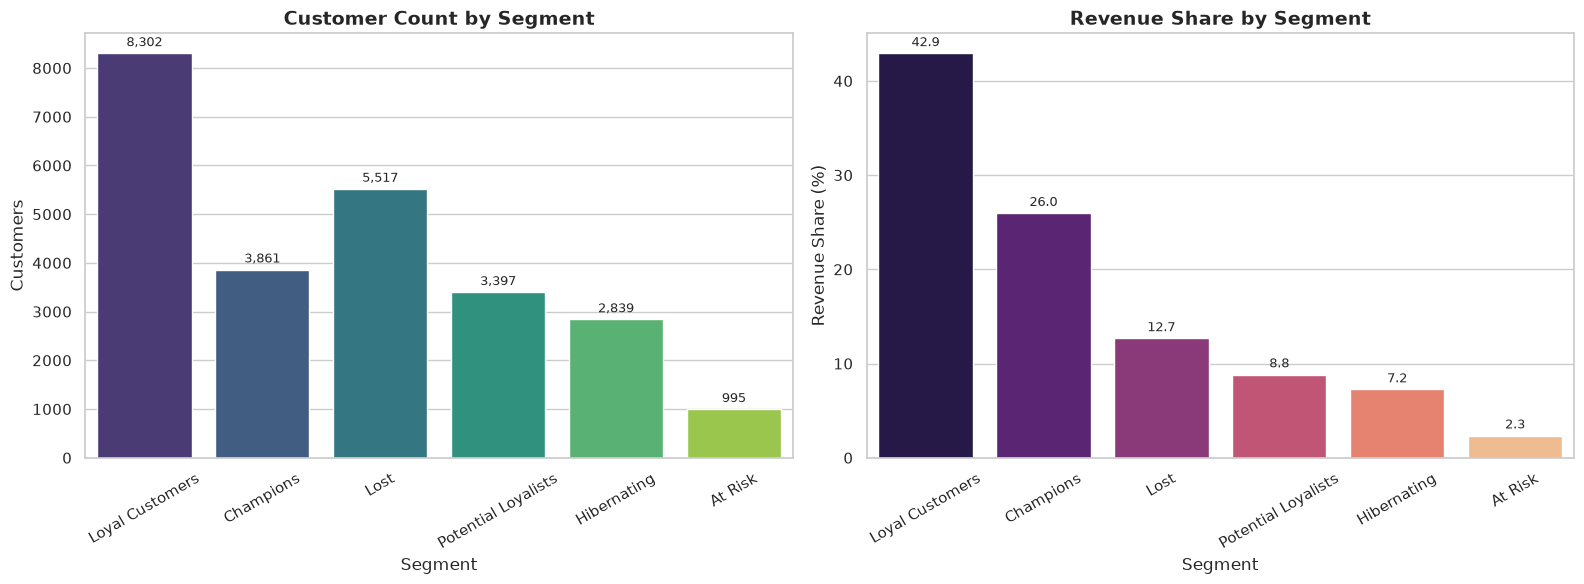

In [24]:
# Visualize segment distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Customer count
sns.barplot(data=rfm_summary, x='RFM_Segment', y='customer_count', 
            palette='viridis', ax=axes[0])
axes[0].set_title('Customer Count by Segment', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Customers')
axes[0].tick_params(axis='x', rotation=30)
add_bar_labels(axes[0])

# Revenue share
sns.barplot(data=rfm_summary, x='RFM_Segment', y='revenue_share_%', 
            palette='magma', ax=axes[1])
axes[1].set_title('Revenue Share by Segment', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Revenue Share (%)')
axes[1].tick_params(axis='x', rotation=30)
add_bar_labels(axes[1], fmt='.1f')

plt.tight_layout()
plt.show()

### RFM Insights

- **Top performers:** Champions (16%) and Loyal Customers (33%) drive 69% of revenue
- **Win-back opportunity:** Hibernating customers (21%) represent $27M in historical value
- **Growth target:** Potential Loyalists (14%) have recent engagement but low frequency

**Actions:**
- Give Champions/Loyal Customers VIP perks, not discounts
- Send Potential Loyalists targeted cross-sell offers within 14 days of purchase
- Deploy automated win-back campaigns for Hibernating/At-Risk segments

## 5. Customer Demographics

Understanding who our high-value customers are.

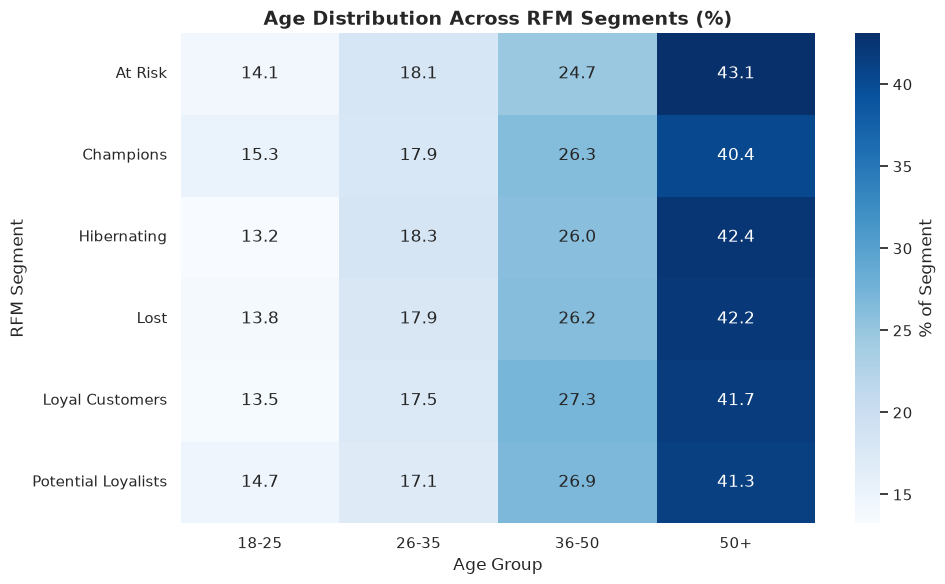


Demographic breakdown:


age_group,18-25,26-35,36-50,50+
RFM_Segment,,,,
At Risk,14.1,18.1,24.7,43.1
Champions,15.3,17.9,26.3,40.4
Hibernating,13.2,18.3,26.0,42.4
Lost,13.8,17.9,26.2,42.2
Loyal Customers,13.5,17.5,27.3,41.7
Potential Loyalists,14.7,17.1,26.9,41.3


In [25]:
# Merge demographics with RFM
cust_profiles = master_df[['customer_id', 'gender', 'customer_age', 'customer_segment', 
                            'customer_country', 'region']].drop_duplicates(subset=['customer_id'])
rfm_demo = rfm_df.merge(cust_profiles, on='customer_id', how='left')

# Age groups
rfm_demo['age_group'] = pd.cut(rfm_demo['customer_age'], 
                                bins=[17, 25, 35, 50, 100],
                                labels=['18-25', '26-35', '36-50', '50+'])

# Age distribution by segment
age_rfm = pd.crosstab(rfm_demo['RFM_Segment'], rfm_demo['age_group'], normalize='index') * 100

plt.figure(figsize=(10, 6))
sns.heatmap(age_rfm, annot=True, fmt='.1f', cmap='Blues', cbar_kws={'label': '% of Segment'})
plt.title('Age Distribution Across RFM Segments (%)', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('RFM Segment')
plt.tight_layout()
plt.show()

print('\nDemographic breakdown:')
display(age_rfm.round(1))

### Demographic Insights

- **Mature customers dominate:** 67% of all segments are aged 36+
- **Gender neutral:** Value is independent of gender (roughly 50/50 split)
- **Account tier mismatch:** 54% of RFM Champions are labeled as basic "Consumer" accounts

**Actions:**
- Target marketing to 36-50 and 50+ age groups
- Auto-upgrade high-value RFM customers to VIP status regardless of current tier

## 6. Product Performance

Identifying profitable products and categories.

PRODUCT CATEGORY PERFORMANCE


,product_category,total_sales,total_profit,order_count,total_qty,margin_pct,avg_rating
4,Electronics,41148162.90,14103982.74,24235,55784,34.28,3.68
10,Jewelry,25561333.78,10391635.32,21578,48859,40.65,3.71
9,Home Appliances,24842478.64,10288878.45,24241,56281,41.42,3.58
0,Automotive,16449898.28,6477194.28,25103,58046,39.38,3.64
13,Sports & Outdoors,15726848.17,7230037.31,27700,64752,45.97,3.77
8,Home & Kitchen,10971629.82,5203824.25,21744,49682,47.43,3.64
1,Baby & Kids,9690605.60,4818148.07,23389,53945,49.72,3.73
7,Health & Wellness,9228068.04,4263304.41,26468,62054,46.20,3.59
11,Office Supplies,8884212.85,4585377.04,24908,57631,51.61,3.71
5,Fashion,7434589.51,3669631.60,21255,48774,49.36,3.68


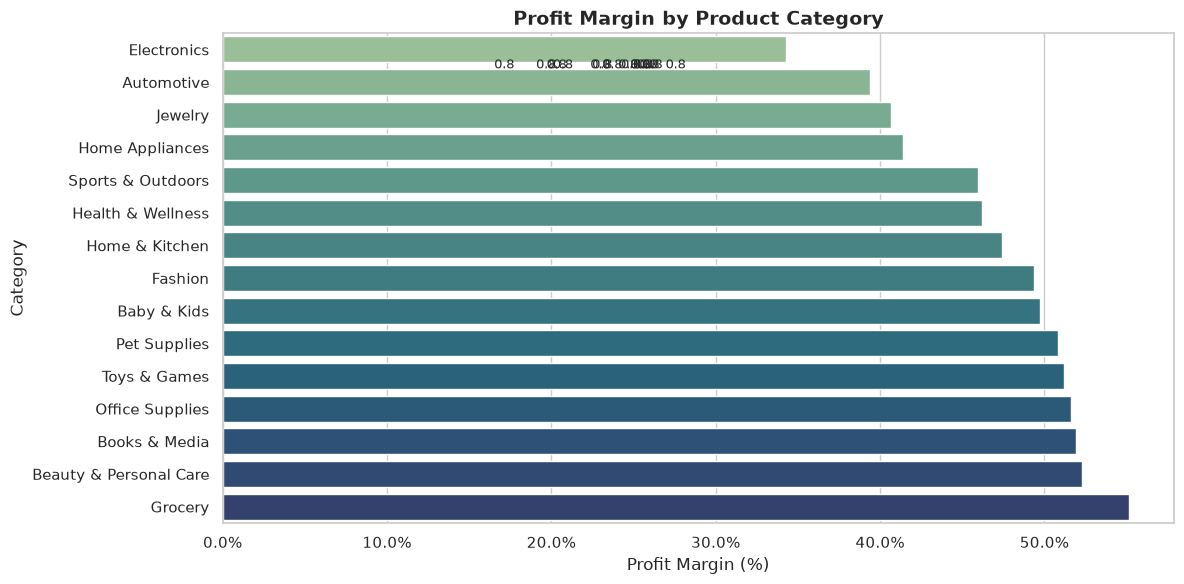

In [26]:
# Category performance using utility function
cat_perf = aggregate_performance(master_df, 'product_category')
cat_perf['avg_rating'] = master_df.groupby('product_category')['product_rating'].mean().values
cat_perf = cat_perf.sort_values('total_sales', ascending=False)

print('PRODUCT CATEGORY PERFORMANCE')
print('='*60)
display(cat_perf.round(2))

# Visualize margin by category
fig, ax = plt.subplots(figsize=(12, 6))
cat_sorted = cat_perf.sort_values('margin_pct')
sns.barplot(data=cat_sorted, x='margin_pct', y='product_category', palette='crest', ax=ax)
ax.set_title('Profit Margin by Product Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Profit Margin (%)')
ax.set_ylabel('Category')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_percentage))
add_bar_labels(ax, fmt='.1f')

plt.tight_layout()
plt.show()

### Product Insights

- **Top revenue:** Electronics ($41M), Jewelry ($26M), Home Appliances ($25M)
- **Best margins:** Grocery (55%), Beauty (52%), Office Supplies (52%)
- **Strategy:** Balance high-revenue Electronics with high-margin categories

**Actions:**
- Prioritize inventory for top revenue + high margin categories
- Review supplier costs for low-margin products

## 7. Discount Impact Analysis

How discounting affects profitability.

DISCOUNT IMPACT


,discount_bin,line_items,total_sales,total_profit,avg_discount,margin_pct
0,0-10%,166516,83821557.20,42536121.29,3.72,50.75
1,10-20%,132328,58099538.58,25775830.90,15.00,44.36
2,20-30%,49819,24541492.54,9217266.99,24.10,37.56
3,30-40%,23230,13794439.68,3938113.43,34.56,28.55
4,40%+,25676,12141849.29,1230705.94,48.27,10.14


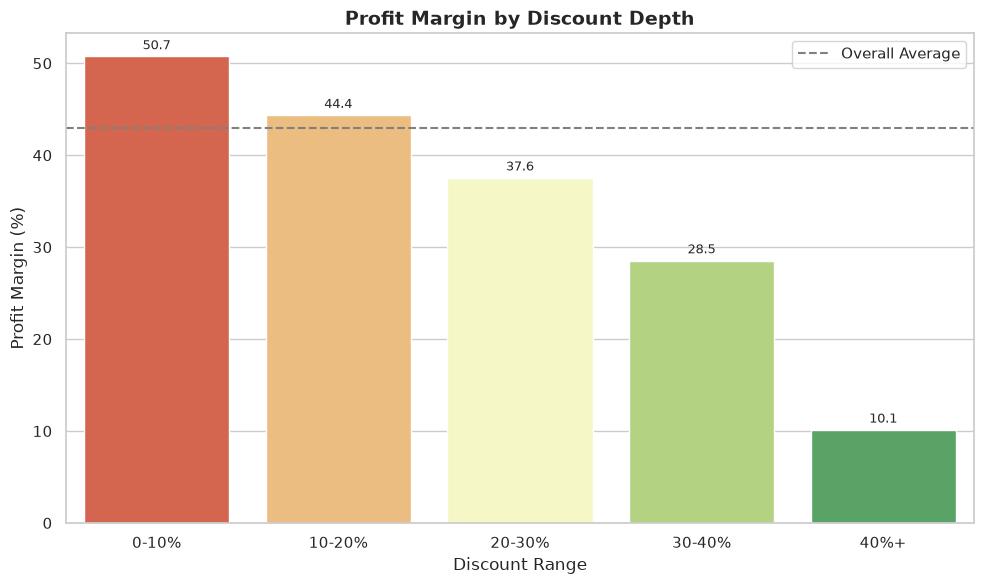

In [27]:
# Bin discounts
master_df['discount_bin'] = pd.cut(
    master_df['discount_percentage'],
    bins=[-0.01, 10, 20, 30, 40, np.inf],
    labels=['0-10%', '10-20%', '20-30%', '30-40%', '40%+'],
    include_lowest=True
)

discount_summary = master_df.groupby('discount_bin', observed=False).agg(
    line_items=('order_id', 'size'),
    total_sales=('net_sales', 'sum'),
    total_profit=('profit', 'sum'),
    avg_discount=('discount_percentage', 'mean')
).reset_index()

discount_summary['margin_pct'] = safe_profit_margin(
    discount_summary['total_profit'], 
    discount_summary['total_sales']
)

print('DISCOUNT IMPACT')
print('='*60)
display(discount_summary.round(2))

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=discount_summary, x='discount_bin', y='margin_pct', 
            palette='RdYlGn', ax=ax)
ax.set_title('Profit Margin by Discount Depth', fontsize=14, fontweight='bold')
ax.set_xlabel('Discount Range')
ax.set_ylabel('Profit Margin (%)')
ax.axhline(y=avg_profit_margin, color='gray', linestyle='--', label='Overall Average')
ax.legend()
add_bar_labels(ax, fmt='.1f')

plt.tight_layout()
plt.show()

### Discount Insights

- **Clear trend:** Margin drops from 51% (0-10% discount) to 10% (40%+ discount)
- **Deep discount risk:** 40%+ discounts significantly erode profitability
- **Sweet spot:** Keep most promotions under 20% discount

**Actions:**
- Set 20% as max discount for most campaigns
- Avoid blanket discounts for Champions/Loyal customers
- Test non-price incentives (early access, free shipping)

## 8. Returns Analysis

Understanding return patterns and costs.

In [28]:
# Calculate return flag
return_clean = master_df['return_status'].fillna('No Return').astype(str).str.strip().str.lower()
master_df['is_returned'] = ~return_clean.isin(['no return', 'not returned', 'nan', 'none', ''])

# Order-level return rate
order_returns = master_df.groupby('order_id').agg(
    order_date=('order_date', 'first'),
    customer_id=('customer_id', 'first'),
    order_profit=('profit', 'sum'),
    order_sales=('net_sales', 'sum'),
    returned=('is_returned', 'max')
).reset_index()

overall_return_rate = order_returns['returned'].mean() * 100

print('RETURNS ANALYSIS')
print('='*60)
print(f'Overall order return rate: {overall_return_rate:.2f}%')

# Top return reasons
return_reasons = master_df.loc[master_df['is_returned'], 'return_reason'].value_counts().head(8)
print(f'\nTop return reasons:')
for reason, count in return_reasons.items():
    print(f'  {reason}: {count:,} items')

# Product categories with highest return rates
product_returns = master_df.groupby('product_category').agg(
    line_items=('order_id', 'size'),
    returned_items=('is_returned', 'sum')
).reset_index()
product_returns['return_rate_%'] = (product_returns['returned_items'] / product_returns['line_items']) * 100
product_returns = product_returns.sort_values('return_rate_%', ascending=False)

print(f'\nCategories with highest return rates:')
display(product_returns.head(10).round(2))

RETURNS ANALYSIS
Overall order return rate: 6.85%

Top return reasons:
  Wrong Product: 3,482 items
  Changed Mind: 3,468 items
  Other: 3,429 items
  Defective Product: 3,423 items
  Size Issue: 3,398 items
  Late Delivery: 3,366 items
  Damaged Product: 3,339 items
  Product Not as Expected: 3,304 items

Categories with highest return rates:


,product_category,line_items,returned_items,return_rate_%
0,Automotive,27480,1988,7.23
10,Jewelry,23254,1626,6.99
8,Home & Kitchen,23471,1641,6.99
7,Health & Wellness,29188,2037,6.98
4,Electronics,26387,1841,6.98
13,Sports & Outdoors,30594,2125,6.95
6,Grocery,26366,1815,6.88
3,Books & Media,29363,2001,6.81
9,Home Appliances,26406,1793,6.79
11,Office Supplies,27237,1843,6.77


### Returns Insights

- **Return rate:** Track this metric monthly as operational KPI
- **Top reasons:** Wrong product, changed mind, defective, size issues
- **Category variation:** Some categories have higher return rates

**Actions:**
- Investigate high-return categories for quality issues
- Improve product descriptions to reduce "wrong product" returns
- Add size guides to reduce size-related returns
- Track full return cost (shipping + handling + resale loss)

## 9. Strategic Recommendations

### Customer Strategy
1. **Protect high-value customers:** Give Champions and Loyal Customers service benefits and early access, not blanket discounts
2. **Convert potential:** Send Potential Loyalists timely cross-sell offers within 14 days of purchase
3. **Win-back campaigns:** Target Hibernating customers with high historical value

### Product Strategy
1. **Focus on winners:** Prioritize inventory for high-revenue, high-margin categories
2. **Quality review:** Investigate high-return products for quality/packaging issues
3. **Supplier negotiations:** Review costs for low-margin products

### Pricing Strategy
1. **Smart discounting:** Keep promotions under 20% to protect margins
2. **Segment-based offers:** Avoid discounting for Champions (try non-price incentives)
3. **Monitor impact:** Track margin alongside revenue, not revenue alone

### Seasonal Strategy
1. **Q4 preparation:** Allocate 30% of annual resources for Nov-Dec peak
2. **Q1 engagement:** Launch clearance campaigns in February to smooth seasonal dip

### Operational Improvements
1. **Return tracking:** Monitor unique-order return rate monthly
2. **Quality ownership:** Assign owners to top return reasons with reduction targets
3. **Regular monitoring:** Re-run this analysis quarterly to track progress